In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'notebook', 'no-latex'])
from scipy.special import wofz

## Optical Depth

How to calculate optical depth of a particular line of sight, by integrating over a range of redshifts through a cloud.

\begin{align*}
    \tau(z_0) = \frac{c I_\alpha}{\sqrt{\pi}} \int \frac{n_\mathrm{HI}}{b(1+z)}\,\,v\left(\frac{\Gamma \lambda_\mathrm{Ly\alpha}}{4\pi b}, \frac{c[x(x)-z_0]}{b(1+z_0)}+\frac{v}{b}\right)\,\,dx
\end{align*}

where,
\begin{align*}
    I_\alpha &= \frac{\pi e^2 f_{osc}}{m_e c \nu_{12}}\\
    &= \frac{\pi \times (4.8\times 10^{-10})^2 \times 0.416}{9.1 \times 10^-27 \times 3 \times 10^10 \times 2.466 \times 10^{15}}\\
    &= 4.45 \times 10^{-18} \mathrm{ cm}^2
\end{align*}


In [3]:
# unit_conversion_paramters
kms_to_cms = 1e5
mpc_to_cm = 3.086e24
ang_to_cm = 1e-8

# physical_constants
c = 2.99792458e10
kB = 1.380658e-16
mp = 1.6726e-24
me = 9.1094e-28
mn = 1.6749286e-24

# cosmological parameters
omega_m = 0.308
omega_l  = 0.692
omega_r  = 0.0
omega_k = 0.0
omega_b = 0.0482
hubble_param = 0.678
sigma_8 = 0.829
Y  = 0.24
ns = 0.961

# atomic_constants
# for Ly alpha
lambda_r = 1215.6701
f12 = 0.416
damp_gamma = 6.265e8
ialpha = 4.469e-18
np_ = 1
ne = 1
nn = 0

In [2]:
def calculate_profile(z_val,z_arr,vXI_arr_1d,bXI_arr_1d,nXI_arr_1d, lambda_in_cm, damp_gamma, c):
    # note: everything here is in CGS (cm/s)
    velocity_factor_array = (vXI_arr_1d + (c*(z_arr-z_val)/(1+z_val)))/bXI_arr_1d
    alpha_factor_arr = (damp_gamma*lambda_in_cm)/(4*np.pi*bXI_arr_1d)
    z_complex_arr = velocity_factor_array + 1j*alpha_factor_arr
    voigt_calc = wofz(z_complex_arr).real
    tau_val_pixel = np.sum(nXI_arr_1d*voigt_calc/(bXI_arr_1d*(1.0+z_arr)), axis=0)
    return tau_val_pixel

In [ ]:
# implement periodic boundary conditions
def calculate_profile_with_BCs(z_val,z_arr,vXI_arr_1d,bXI_arr_1d,nXI_arr_1d, lambda_in_cm, damp_gamma, c):
    # note: everything here is in CGS (cm/s)
    velocity_factor_array = (vXI_arr_1d + (c*(z_arr-z_val)/(1+z_val)))/bXI_arr_1d
    alpha_factor_arr = (damp_gamma*lambda_in_cm)/(4*np.pi*bXI_arr_1d)
    z_complex_arr = velocity_factor_array + 1j*alpha_factor_arr
    voigt_calc = wofz(z_complex_arr).real
    tau_val_pixel = np.sum(nXI_arr_1d*voigt_calc/(bXI_arr_1d*(1.0+z_arr)), axis=0)
    return tau_val_pixel

In [5]:
# download from https://people.ast.cam.ac.uk/~pgaikwad/IUCAA_SCHOOL/Spectra_Fields.npy
fields = np.load('Spectra_Fields.npy', allow_pickle=True, encoding='latin1').item()

In [6]:
z_field = '2.0'
inp = fields['2.0'] # consider z = 2
inp.keys()

dict_keys(['v_gas_arr', 'tau_HI_arr', 'Delta_arr', 'T_gas_arr', 'f_HI_arr', 'z_arr', 'n_HI_arr'])

In [8]:
z_arr = inp['z_arr']
v_gas_arr = inp['v_gas_arr']*kms_to_cms
n_HI_arr = inp['n_HI_arr']
T_gas_arr = inp['T_gas_arr']
tau_HI_arr_ref = inp['tau_HI_arr']
tau_HI_arr = np.zeros(tau_HI_arr_ref.shape) # we will compute tau for comparison

f_HI_arr = inp['f_HI_arr']
Delta_arr = inp['Delta_arr']
b_gas_arr = np.sqrt(2*kB*T_gas_arr/(mp+me)) 

In [20]:
npixel = 2048
nlos = 500
lambda_in_cm = lambda_r*ang_to_cm
dl_box_cm = 40*mpc_to_cm/npixel/hubble_param

In [21]:
def generate_spectra(z_arr,n_HI_arr_1d,b_gas_arr_1d,v_gas_arr_1d,tau_HI_arr_1d):
    for pixel_idx in range(npixel):
        z_val = z_arr[pixel_idx]
        tau_HI_arr_val = calculate_profile(z_val,z_arr,v_gas_arr_1d,b_gas_arr_1d,n_HI_arr_1d,lambda_in_cm, damp_gamma, c)
        tau_HI_arr_1d[pixel_idx] = tau_HI_arr_val

    tau_HI_arr_1d = tau_HI_arr_1d*c*ialpha*dl_box_cm/np.sqrt(np.pi)
    return tau_HI_arr_1d

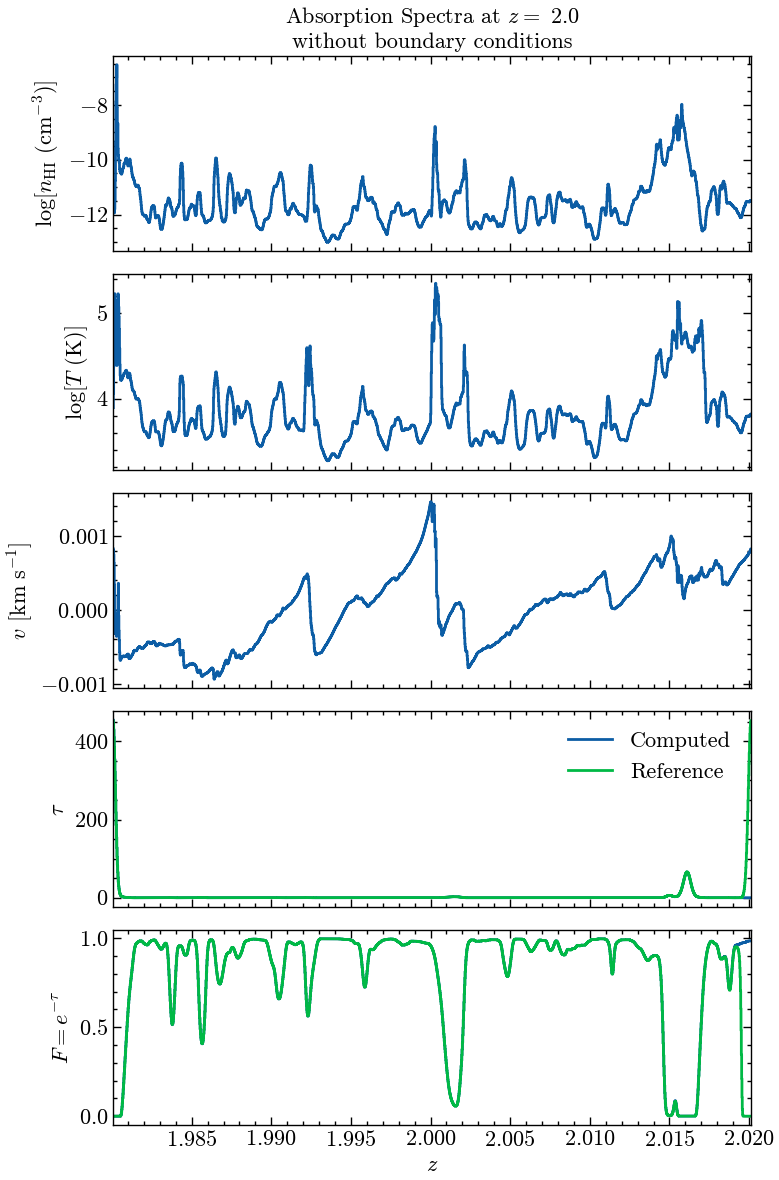

In [ ]:
for los_idx in [0]:#range(nlos):
    n_HI_arr_1d = n_HI_arr[:,los_idx]
    b_gas_arr_1d = b_gas_arr[:,los_idx]
    v_gas_arr_1d = v_gas_arr[:,los_idx]
    tau_HI_arr_1d = tau_HI_arr[:, los_idx]

    tau_HI_arr_1d = generate_spectra(z_arr,n_HI_arr_1d,b_gas_arr_1d,v_gas_arr_1d,tau_HI_arr_1d)
    tau_HI_arr[:,los_idx] = tau_HI_arr_1d # update with computed tau

    # now plot
    fig, ax = plt.subplots(nrows=5,sharex=True, figsize=(8,12))

    ax[0].step(z_arr, np.log10(n_HI_arr[:,los_idx]))
    ax[1].step(z_arr, np.log10(T_gas_arr[:, los_idx]))
    ax[2].step(z_arr, v_gas_arr[:, los_idx] / kms_to_cms) 
    ax[3].step(z_arr, tau_HI_arr[:, los_idx], label='Computed')
    ax[3].step(z_arr, tau_HI_arr_ref[:, los_idx], label='Reference')
    ax[4].step(z_arr, np.exp(-tau_HI_arr[:, los_idx]))
    ax[4].step(z_arr, np.exp(-tau_HI_arr_ref[:, los_idx]))
    
    ax[3].legend()
    ax[0].set_ylabel(r'$\log [n_\mathrm{HI}$ (cm$^{-3}$)]')
    ax[1].set_ylabel(r'$\log [T$ (K)]')
    ax[2].set_ylabel(r'$v$ [km s$^{-1}$]')
    ax[3].set_ylabel(r'$\tau$')
    ax[4].set_ylabel(r'$F = e^{-\tau}$')
    ax[4].set_xlabel(r'$z$')
    ax[4].set_xlim(z_arr[0],z_arr[-1])

    ax[0].set_title(f'Absorption Spectra at $z =$ {z_field}\nwithout boundary conditions')

    plt.tight_layout()
    plt.savefig('figures/real_lines_2.png')
    plt.show()
    plt.close()

    break 